In [1]:
import pyflubl
import numpy as np
import matplotlib.pyplot as plt

initializing ocelot...


## Prepare a simple beamline example

### Create machine object and add defaults

In [2]:
m = pyflubl.BuilderNew.Machine(bakeTransforms=True)
d = pyflubl.Fluka.Defaults('EM-CASCA')
m.AddDefaults(d)

### Add some elements to the line

In [3]:
m.AddDrift(name="d1",length=1.0);
m.AddSamplerPlane(name="d1s", length=1e-6);
m.AddQuadrupole(name="q1",length=0.25, k1=-0.5);
m.AddSamplerPlane(name="q1s",length=1e-6);
m.AddSBendSplit(name="sb1",length=2, angle=5/180*np.pi, nsplit=10);
m.AddDrift(name="d2",length=1.0);
m.AddTarget(name="t1", length=0.02, material="IRON");
m.AddSamplerPlane(name="t1s",length=1e-6)
m.AddDrift(name="d3",length=1.0);
m.AddSamplerPlane(name="d3s",length=1e-6)

### Add the beam

In [4]:
b = pyflubl.Fluka.Beam(momentumOrKe=1, energySpread=0, sdum="ELECTRON")
bp = pyflubl.Fluka.Beampos(xCentre=0, yCentre=0, zCentre=0, xCosine=0, yCosine=0)
ba = pyflubl.Fluka.BeamAxes(xxCosine=1, xyCosine=0, xzCosine=0,
                          zxCosine=0, zyCosine=0, zzCosine=1)

m.AddBeam(b)
m.AddBeampos(bp)
m.AddBeamaxes(ba)

### Add user calls required for full pyflubl functionality

In [5]:
uic = pyflubl.Fluka.Usricall()
m.AddUsricall(uic)

ud = pyflubl.Fluka.Userdump(mgdraw=100,lun=23,mgdrawOption=-1,userDump=None, outputFile="dump")
m.AddUserdump(ud)

uoc = pyflubl.Fluka.Usrocall()
m.AddUsrocall(uoc)

### Add scoring mesh

In [6]:
eb = pyflubl.Fluka.Usrbin(binning=pyflubl.Fluka.Usrbin.CARTESIAN_STEP,
                           particle="ALL-PART",lun=-24,
                           xmax=50, ymax=50, zmax=100, sdum="eb",
                           xmin=-50, ymin=-50, zmin=-100,
                           nxbin=101, nybin=101, nzbin=101)
m.AddUsrbinToElement("t1", eb)

### Random and start

In [7]:
r = pyflubl.Fluka.Randomiz()
m.AddRandomiz(r)

s = pyflubl.Fluka.Start(100)
m.AddStart(s)

### Write output files

In [8]:
# coordinates and bounding geometry of beamline
m.SaveJSON("01_Analysis_coordinates.json")

# fluka output files
m.Write("01_Analysis")

## Loading coordinates and plotting simulation bounding geometry

In [9]:
# create coordinate object
coords = pyflubl.Coordinates.Coordinates()

# load coordinate file 
coords.LoadJSON("./01_Analysis_coordinates.json")

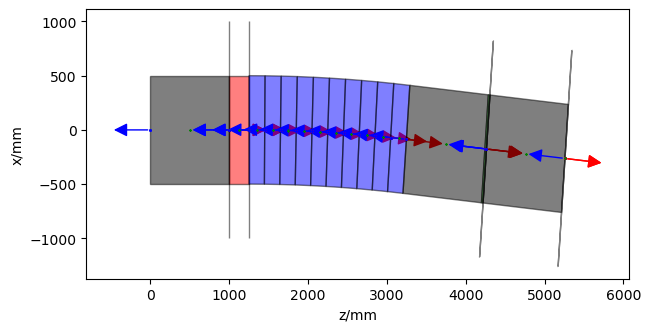

In [10]:
pyflubl.Analysis.plot_coordinates_projection(coords,projection="zx");

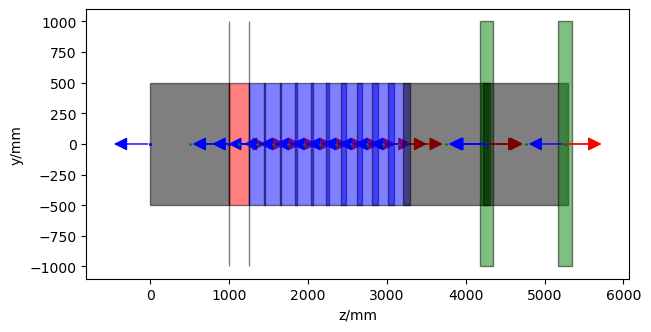

In [11]:
pyflubl.Analysis.plot_coordinates_projection(coords,projection="zy");

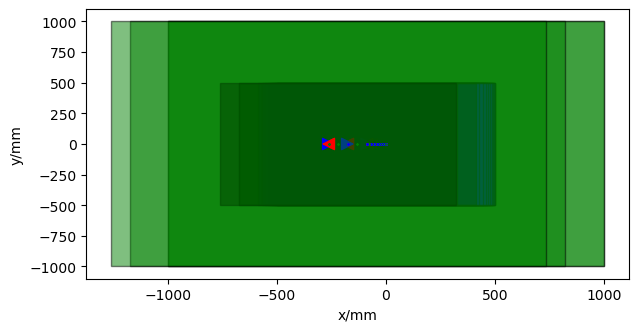

In [12]:
pyflubl.Analysis.plot_coordinates_projection(coords,projection="xy");

## Running FLUKA

In [13]:
pyflubl.Utilities.clear_flukarun()

## Loading output and making some plots

In [2]:
o = pyflubl.Analysis.PyflublOutput(jsonFileName="./01_Analysis.json",
                                   jsonCoordinateFileName="./01_Analysis_coordinates.json",
                                   rootFileName="./01_Analysis001_pyflubl.root",
                                   dumpFileName="./01_Analysis001_dump",
                                   usrbinFileName="./01_Analysis001_fort.24")

Read 1 detectors
No statistics


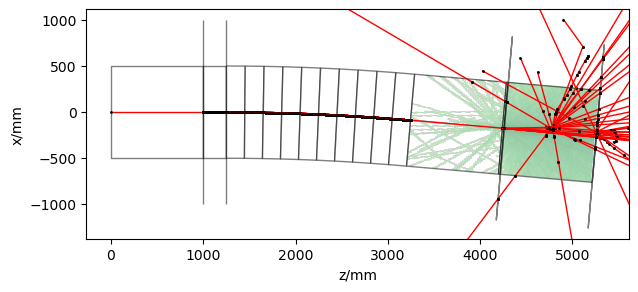

In [15]:
o.plot_projection(projection="zx",detector=-1);

### Getting individual sampler data

In [16]:
o.get_sampler_names()

['d1s', 'q1s', 't1s', 'd3s']

In [10]:
q1s = o.get_sampler('t1s')

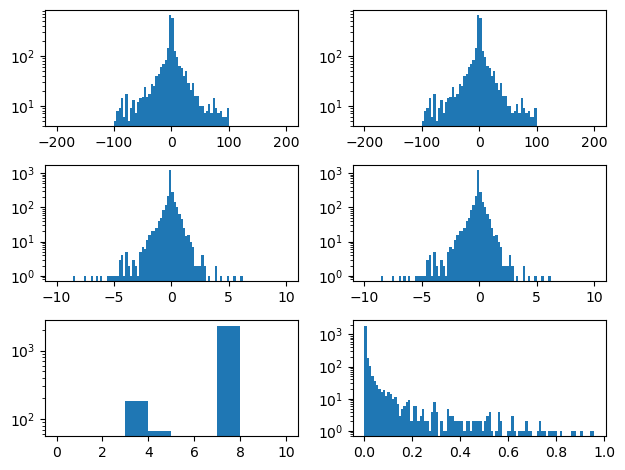

In [27]:
plt.subplot(3,2,1)
plt.hist(q1s['x'],100, (-200,200));
plt.yscale("log")
plt.subplot(3,2,2)
plt.hist(q1s['y'],100, (-200,200));
plt.yscale("log")

plt.subplot(3,2,3)
plt.hist(q1s['xp'],100,(-10,10));
plt.yscale("log")
plt.subplot(3,2,4);
plt.hist(q1s['yp'], 100, (-10,10));
plt.yscale("log")

plt.subplot(3,2,5)
plt.hist(q1s['partID'],10,(0,10));
plt.yscale("log")
plt.subplot(3,2,6)
plt.hist(q1s['energy'],100);
plt.yscale("log")

plt.tight_layout()

### Getting energy loss

In [3]:
eloss = o.get_eloss()

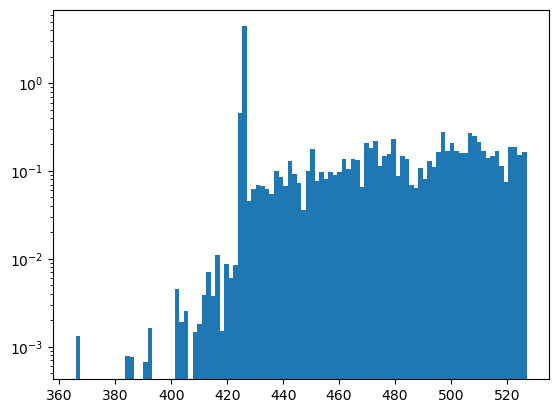

In [29]:
plt.hist(eloss['S'], 100, weights=eloss['E']);
plt.yscale("log")